# Задача по анализу поиска в Яндекс Картинках

Миллионы людей ежедневно пользуются поиском по картинкам в Яндексе, решая разнообразные задачи.

Команда Яндекса прикладывает много усилий чтобы сделать сервис более полезным и удобным для использования.

Но для этого нужно хорошо понимать задачи, которые решают пользователи. К примеру, есть гипотеза, что интересы людей, пользующихся поиском по картинкам на мобильных устройствах и на компьютерах заметно отличаются. Вам нужно проверить эту гипотезу, сравнив запросы на разных платформах.
В файле data.tsv лежит семпл запросов к Яндекс Картинкам за несколько недель.

Ваша задача:
1. Укажите даты диапазона, предоставленного вам для анализа?
2. Рассчитайте кол-во запросов с текстом "ютуб"  в каждой платформе (desktop, touch)
3. Выведите топ10 самых частотных запросов в каждой платформе (desktop, touch). Какие отличия вы видите?
4. Посмотрите, чем отличается трафик запросов в течении дня. Как можно объяснить отличие?
5. Выделите тематики запросов, контрастные для мобильных и компьютеров - темы, доля которых отличаются на разных платформах

Предпочтительный формат - Jupyter Notebook с кодом Python и документацией Markdown на своей машине или в собственном инстансе Datasphere. Приветствуется, если вы продемонстрируете в ноутбуке навыки написания select-запросов в SQL (например, с использованием pandasql.sqldf). Также приветствуется, если вы продемонстрируете навыки визуализации данных в Datalens.

In [494]:
!pip install -U pandasql -q
!python -m pip install statsmodels -q
!pip install matplotlib -q
!pip install seaborn -q

In [495]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

from pandasql import sqldf

In [496]:
pysqldf = lambda q: sqldf(q, globals())

## Загрузка данных

In [ ]:
df_requests = pd.read_csv('data.tsv', sep='\t', names=['request', 'date', 'platform'])
print(df_requests['date'][0])
df_requests['date'] = pd.to_datetime(df_requests['date'], unit='s', utc=True).dt.tz_convert('Europe/Moscow')
print(df_requests['date'][0])
df_requests.sample(5)

1631806465
2021-09-16 18:34:25+03:00


,request,date,platform
144080,поздравления с рождением сына,2021-09-01 21:09:13+03:00,touch
481143,карта метро,2021-09-05 18:44:29+03:00,touch
386857,формулы сокращенного умножения,2021-09-07 16:11:27+03:00,touch
748417,дирижабль,2021-09-03 10:47:55+03:00,touch
679687,люди в черном,2021-09-16 07:53:13+03:00,touch


In [498]:
df_requests.info()

<class 'pandas.DataFrame'>
RangeIndex: 1114365 entries, 0 to 1114364
Data columns (total 3 columns):
 #   Column    Non-Null Count    Dtype                       
---  ------    --------------    -----                       
 0   request   1114365 non-null  str                         
 1   date      1114365 non-null  datetime64[s, Europe/Moscow]
 2   platform  1114365 non-null  str                         
dtypes: datetime64[s, Europe/Moscow](1), str(2)
memory usage: 25.5 MB


Данные загружены в data frame из предоставленного файла data.tsv. Добавлены названия колонок. Колонка с timestamp форматом даты оработана для отображения в читаемом виде. Всего 1_114_365 запросов, пропусков нет.

### Задача 1. Укажите даты диапазона, предоставленного вам для анализа

In [499]:
print(f'Диапазон дат: {str(min(df_requests['date'])).split()[0]} - {str(max(df_requests['date'])).split()[0]}')

Диапазон дат: 2021-09-01 - 2021-09-21


In [500]:
pysqldf("""
    SELECT strftime('%Y-%m-%d', min(date)) as from_date,
           strftime('%Y-%m-%d', max(date)) as to_date
    FROM df_requests
    """)

,from_date,to_date
0,2021-09-01,2021-09-21


В файле представлены данные за сентябрь 2021 года с 1 по 21 число.

### Задача 2. Рассчитайте кол-во запросов с текстом "ютуб" в каждой платформе (desktop, touch)

In [501]:
df_req = df_requests.copy()
df_req['request'] = df_req['request'].str.lower()
df_req['request'] = df_req['request'].str.replace('ё', 'e')
# приведение к нижнему регистру и замена 'ё' на 'е'

In [502]:
print('Количество запросов, с текстом "ютуб" (с точным содержанием) для каждой платформы:')
df_req[df_req['request'] == 'ютуб']\
    .drop('date', axis=1)\
    .groupby(['platform'])\
    .count()

Количество запросов, с текстом "ютуб" (с точным содержанием) для каждой платформы:


,request
platform,
desktop,718
touch,611


In [503]:
print('Количество запросов, содержащих текст "ютуб" (помимо "ютуб" могут быть и другие слова)\nдля каждой платформы:')
mask = df_req['request'].str.contains('ютуб')
df_req[mask].drop('date', axis=1)\
    .groupby(['platform'])\
    .count()

Количество запросов, содержащих текст "ютуб" (помимо "ютуб" могут быть и другие слова)
для каждой платформы:


,request
platform,
desktop,806
touch,732


In [504]:
print('Количество запросов, содержащих текст "ютуб" или его английский аналог "youtube"\nдля каждой платформы:')
mask = df_req['request'].str.contains('youtube') + df_req['request'].str.contains('ютуб')
df_req[mask].drop('date', axis=1)\
    .groupby(['platform'])\
    .count()

Количество запросов, содержащих текст "ютуб" или его английский аналог "youtube"
для каждой платформы:


,request
platform,
desktop,1655
touch,891


In [505]:
pysqldf(
    """
    SELECT platform, count(*) as requests_count
    FROM df_req
    WHERE request like '%ютуб%'
    GROUP BY platform
    """
)

,platform,requests_count
0,desktop,806
1,touch,732


In [506]:
pysqldf(
    """
    SELECT platform, count(*) as requests_count
    FROM df_req
    WHERE request like '%ютуб%'
    OR request like '%youtube%'
    GROUP BY platform
    """
)

,platform,requests_count
0,desktop,1655
1,touch,891


Количество запросов со словом "ютуб" или его английским аналогом "youtube" с компьютеров в ~2 раза выше, чем с мобильных устройств.

### Задача 3. Выведите топ10 самых частотных запросов в каждой платформе (desktop, touch). Какие отличия вы видите?

In [507]:
print('Топ 10 зпросов для платформы desktop:')
df_req[df_req['platform'] == 'desktop'].drop('date', axis=1)\
    .groupby(['request'])\
    .count()\
    .sort_values(by='platform', ascending=False)\
    .head(10)

Топ 10 зпросов для платформы desktop:


,platform
request,
календарь 2021,2810
таблица менделеева,2659
картинки,1720
английский алфавит,1352
обои на рабочий стол,1143
одноклассники (социальная сеть),1116
алфавит,923
таблица квадратов,883
таблица умножения,872


In [508]:
print('Топ 10 зпросов для платформы touch:')
df_req[df_req['platform'] == 'touch'].drop('date', axis=1)\
    .groupby(['request'])\
    .count()\
    .sort_values(by='platform', ascending=False)\
    .head(10)

Топ 10 зпросов для платформы touch:


,platform
request,
с днeм рождения женщине,4924
с днeм рождения,4123
с днeм рождения мужчине,3669
с днем рождения,3315
погода,2918
игры,2873
фильмы,2770
новости,2733
музыка,2723


In [509]:
pd.concat([pysqldf(
    """
    SELECT platform, request, count(*) as requests_count
    FROM df_req
    WHERE platform = 'desktop'
    GROUP BY platform, request
    ORDER BY requests_count DESC
    LIMIT 10
    """
), pysqldf(
    """
    SELECT platform, request, count(*) as requests_count
    FROM df_req
    WHERE platform = 'touch'
    GROUP BY platform, request
    ORDER BY requests_count DESC
    LIMIT 10
    """
)
])

,platform,request,requests_count
0,desktop,календарь 2021,2810
1,desktop,таблица менделеева,2659
2,desktop,картинки,1720
3,desktop,английский алфавит,1352
4,desktop,обои на рабочий стол,1143
5,desktop,одноклассники (социальная сеть),1116
6,desktop,алфавит,923
7,desktop,таблица квадратов,883
8,desktop,таблица умножения,872
9,desktop,youtube,838


В зависимости от платформы популярные запросы отличаются.<br>
С **мобильных устройств** наиболее распространённые запрсы для поздравления с днём рождения и достаточно разноплановые общеобзорные темы. <br>
С **компьютеров** запросы больше нацелены на информацию табличного вида, которая нужна под рукой.

### Задача 4. Посмотрите, чем отличается трафик запросов в течении дня. Как можно объяснить отличие?

In [510]:
df_req_counts = df_req.set_index('date')
df_req_counts_common = df_req_counts['request'].resample('1h').count()
df_req_counts_desk = df_req_counts[df_req_counts['platform'] == 'desktop']['request'].resample('1h').count()
df_req_counts_touch = df_req_counts[df_req_counts['platform'] == 'touch']['request'].resample('1h').count()
df_req_counts_common.head()

date
2021-09-01 00:00:00+03:00    1235
2021-09-01 01:00:00+03:00     801
2021-09-01 02:00:00+03:00     737
2021-09-01 03:00:00+03:00     819
2021-09-01 04:00:00+03:00    1111
Freq: h, Name: request, dtype: int64

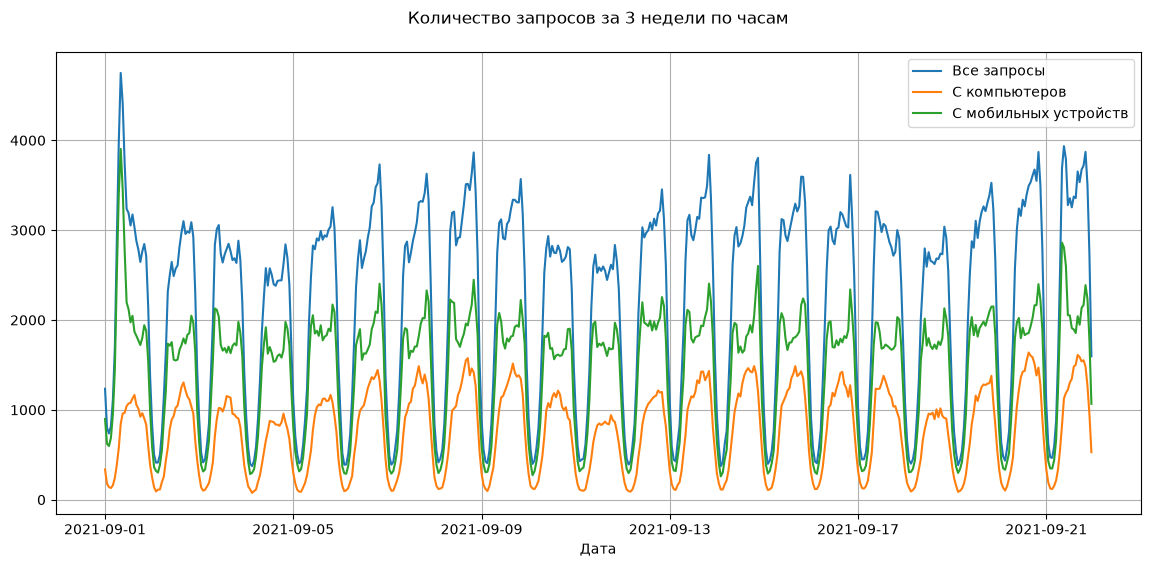

In [511]:
plt.figure(figsize=(14, 6))
plt.plot(df_req_counts_common, label='Все запросы')
plt.plot(df_req_counts_desk, label='С компьютеров')
plt.plot(df_req_counts_touch, label='С мобильных устройств')

plt.title('Количество запросов за 3 недели по часам\n')
plt.xlabel('Дата')
plt.grid()
plt.legend()
plt.show()

Разложение временного ряда на тренд и сезонную компоненту


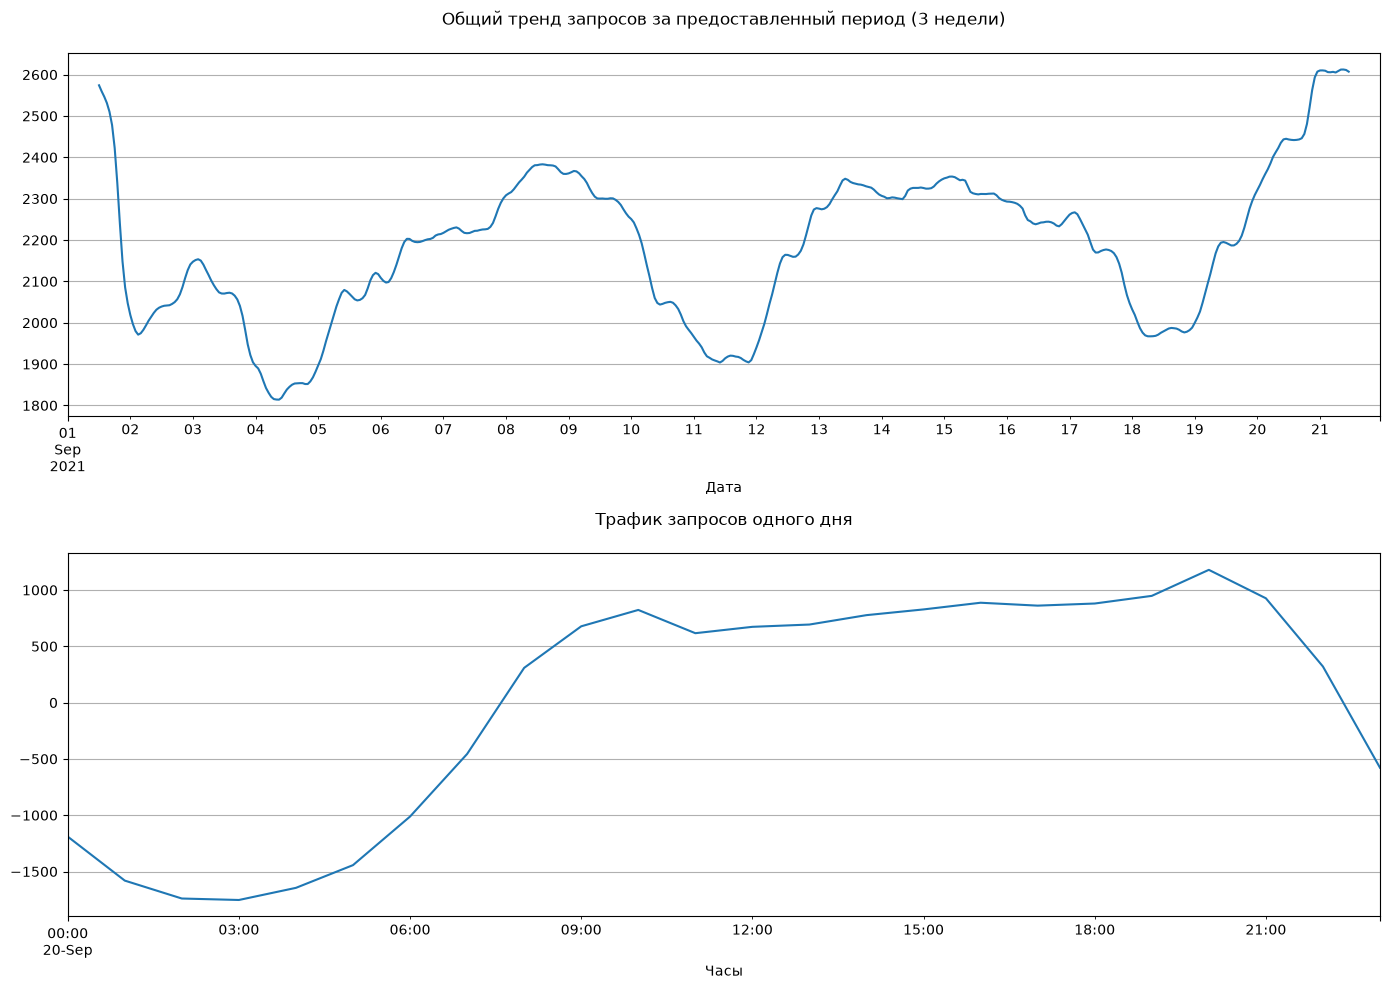

In [512]:
decomposed_common = seasonal_decompose(df_req_counts_common)

print('Разложение временного ряда на тренд и сезонную компоненту')
plt.figure(figsize=(14, 10))

plt.subplot(211)
decomposed_common.trend.plot(ax=plt.gca())
plt.title('Общий тренд запросов за предоставленный период (3 недели)\n')
plt.xlabel('Дата')
plt.grid(True)

plt.subplot(212)
decomposed_common.seasonal['2021-09-20':'2021-09-20'].plot(ax=plt.gca())
plt.title('Трафик запросов одного дня\n')
plt.xlabel('Часы')
plt.grid(True)

plt.tight_layout()

Разложение временного ряда на тренд и сезонную компоненту для запросов с компьютеров


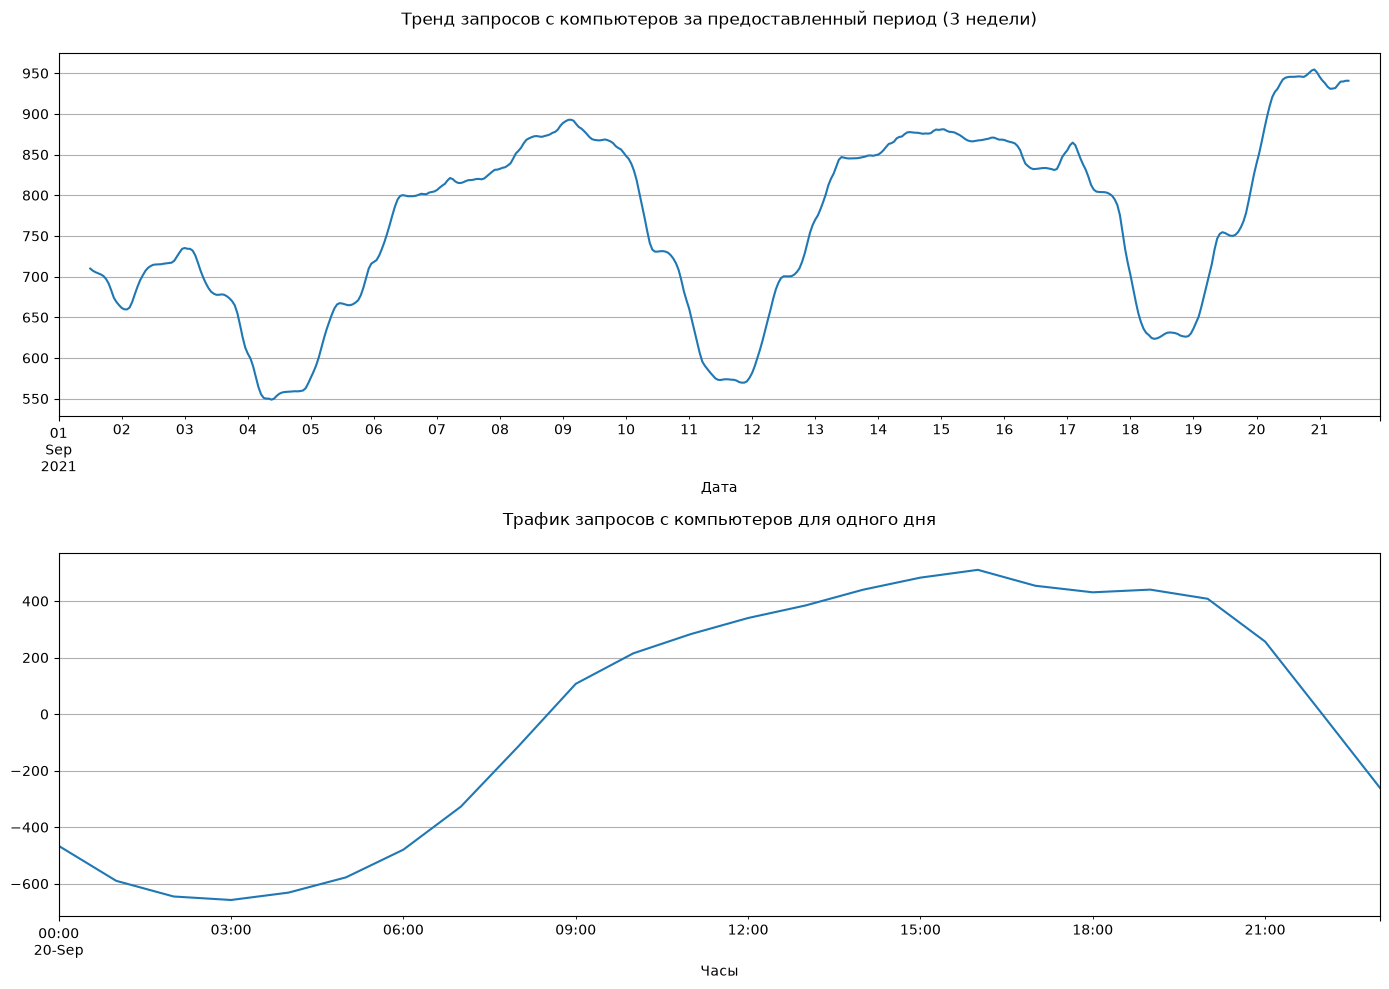

In [513]:
decomposed_desk = seasonal_decompose(df_req_counts_desk)

print('Разложение временного ряда на тренд и сезонную компоненту для запросов с компьютеров')
plt.figure(figsize=(14, 10))

plt.subplot(211)
decomposed_desk.trend.plot(ax=plt.gca())
plt.title('Тренд запросов с компьютеров за предоставленный период (3 недели)\n')
plt.xlabel('Дата')
plt.grid(True)

plt.subplot(212)
decomposed_desk.seasonal['2021-09-20':'2021-09-20'].plot(ax=plt.gca())
plt.title('Трафик запросов с компьютеров для одного дня\n')
plt.xlabel('Часы')
plt.grid(True)

plt.tight_layout()

Разложение временного ряда на тренд и сезонную компоненту для запросов с мобильных устройств


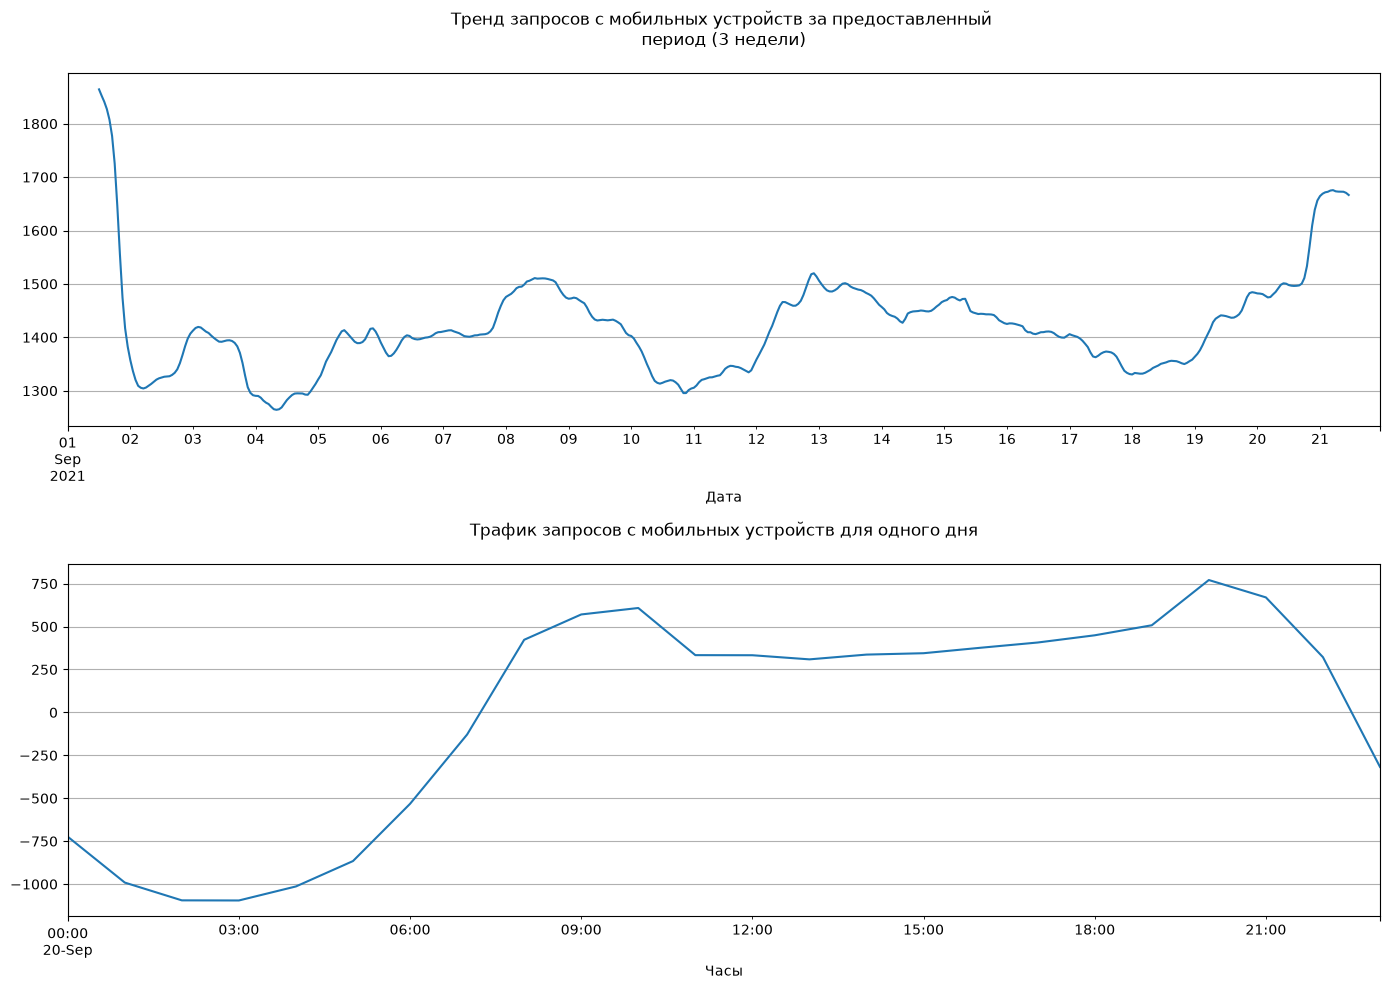

In [514]:
decomposed_touch = seasonal_decompose(df_req_counts_touch)

print('Разложение временного ряда на тренд и сезонную компоненту для запросов с мобильных устройств')
plt.figure(figsize=(14, 10))

plt.subplot(211)
decomposed_touch.trend.plot(ax=plt.gca())
plt.title('Тренд запросов с мобильных устройств за предоставленный \nпериод (3 недели)\n')
plt.xlabel('Дата')
plt.grid(True)

plt.subplot(212)
decomposed_touch.seasonal['2021-09-20':'2021-09-20'].plot(ax=plt.gca())
plt.title('Трафик запросов с мобильных устройств для одного дня\n')
plt.xlabel('Часы')
plt.grid(True)

plt.tight_layout()

При рассмотрении данных за предоставленный период в 3 недели с 1 по 21 сентября 2021 года в часовой зоне Москвы (GMT+3) видна следующая картина:

Общая тенденция запросов в течении дня показывает спад активности в ночное время с 1 до 4 часов и основную активность с 8 до 22 часов.

Для **запросов с компьютеров** минимальная активность в среднем за предоставленный период приходится на 3 часа ночи, наибольшее количество запросов за день выпадает с 13 до 20 часов с пиком в 16 часов.

Для **запросов с мобильных устройств** минимальная активность в среднем за предоставленный период приходится на 2-3 часа ночи, наибольшее количество запросов за день выпадает с 7 до 11 часов и с 18 до 22 часов с пиками в 10 и 20 (наибольший пик) часов соответсвенно. 

Таким образов запрос картинок с компьютера в большенстве случаев нужен в рабочии часы - для работы/учёбы. В то время как запросы с мобильных устройств более востребованы до и после рабочих часов, что объясняет темы наиболее популярных запросов.

### Задача 5. Выделите тематики запросов, контрастные для мобильных и компьютеров - темы, доля которых отличаются на разных платформах

In [515]:
# определение тематик для части запросов

def req_per_subj(text):
    if 'календарь' in text:
        return 'календарь'
    elif any(word in text for word in ['+18', '18+', 'снкс', 'пооно', 'seqs', 'поро', '18 +', '18 плюс', 'порго',
                                        'gay', 'ankha', 'ева эльфи', 'gjhyj', 'apetube', 'pokerdom', 'bokeb besar tetek',
                                        'pap tt', 'казино', 'попно', 'xxn', 'мостбет', 'bokep', 'билли херрингтон',
                                        'abg colmek', 'bugil', '보지', '🍑', 'ngewe']):
        return '18+'
    elif any(word in text for word in ['заставк', 'картин', 'лого', 'wallpaper']):
        return 'обои_логотипы'
    elif any(word in text for word in ['gif', 'гиф', 'доброго', 'доброе', 'с добрым', 'с рождением', 'хорошего']):
        return 'гифки'
    elif any(word in text for word in ['с днeм', 'с днем рождения', 'happy birthday', 'с днем', 'поздравления']):
        return 'поздравления'
    elif any(word in text for word in ['праздник', 'свадьб', 'день', '1 сентября']):
        return 'праздники'
    elif any(word in text for word in ['детск', 'teen', 'раскраска']):
        return 'детское'
    elif any(word in text for word in ['anime', 'аниме', 'анимация', 'boruto', 'furry', 'gven staisse', 'hanabi',
                                        'hinata', 'ino', 'konosuba', 'loli', 'nami', 'naruto', 'one piece',
                                        'tsunade', 'zero two', 'блич', 'ван пис', 'гача лайф']):
        return 'аниме'
    elif 'песн' in text or 'песен' in text or 'слушать' in text:
        return 'песни'
    elif any(word in text for word in ['рик и морти', 'хабиб', 'сектор газа', 'борис краснов', 'а4','видео а 4',
                                        'влада а 4', 'группа', 'газманов', 'стас намин', 'лсп', 'хэллоу китти',
                                        'дмитрий комаров', 'наташа королева', 'aknsha', 'billie eilish', 'hannah',
                                        'mackenzie jones', 'мамаев', 'белла порч', 'белла торн', 'билли айлиш', 'валя карнавал',
                                        'дженнифер', 'тэхен', 'гульчехра эшонкулова']):
        return 'знаменитости'
    elif any(word in text for word in ['игр', 'майнкрафт', 'brawl starts', 'call of duty', 'diablo', 'dota', 'fallout',
                                        'far cry', 'fnaf ', 'fortnite', 'friday night funkin', 'genshin', 'god of war',
                                        'gta', 'mobile legend', 'roblox', 'trish', 'war thunder', 'warcraft', 'world of thanks',
                                        'амонг ас', 'бравл старс', 'браво старс', 'гта', 'counter-strike', 'zuma', 'stalker',
                                        'hello neighbor', 'ведьмак 3', 'counter strike', 'hearts of iron']):
        return 'игры' # нужно разделение на игры для ПК и игры для телефонов
    elif any(word in text for word in ['мульт', 'свинка пеппа', 'синий трактор', '3 кота',
                                        'мегамозг', 'гравити фолз', 'сказочный патруль', 'cartoon']):
        return 'мультфильмы'
    elif any(word in text for word in ['фильм', 'кино', 'смотреть', 'боевик', 'сериал', 'обитель зла', 'harry potter',
                                        'гарри поттер', 'video', 'видео', '视频']):
        return 'фильмы'
    elif any(word in text for word in ['одноклассники', 'facebook']):
        return 'соц.сети'
    elif any(word in text for word in ['iphone', 'айфон']):
        return 'телефоны'
    elif 'наука' in text:
        return 'наука'
    elif any(word in text for word in ['образова', 'культура', 'гдз', 'класс', 'liseli', 'алфавит', 'атлас', 'букв',
                                        'загадк', 'закон ньютона', '1 склонение', 'прописи']):
        return 'образование'
    elif 'музыка' in text:
        return 'музыка'
    elif 'новост' in text:
        return 'новости'
    elif 'таблица' in text:
        return 'таблицы'
    elif 'истори' in text:
        return 'история'
    elif '13 карт' in text:
        return '13 карт'
    elif 'заповед' in text:
        return 'заповеди'
    elif any(word in text for word in ['спорт', 'футбол', 'кхл', 'лч', 'фнл', 'чемпионат', 'mikasa', 'баскетбол']):
        return 'спорт'
    elif 'мода' in text or 'дизайн' in text:
        return 'мода'
    elif any(word in text for word in ['здоровь', 'коронавирус', 'грибок', 'таблетки', 'герпес', 'витамин', 'вакцинац']):
        return 'здоровье'
    elif 'психологи' in text:
        return 'психология'
    elif 'технологи' in text:
        return 'технологии'
    elif 'перевод' in text:
        return 'переводчик'
    elif any(word in text for word in ['литератур', 'стих', 'басн', 'пословиц']):
        return 'литература'
    elif 'кулинар' in text or 'рецепт' in text or 'лечо' in text or 'кабачковая икра' in text:
        return 'кулинария'
    elif 'погод' in text:
        return 'погода'
    elif 'путешеств' in text:
        return 'путешествия'
    elif 'карта' in text:
        return 'карта'
    elif any(word in text for word in ['audi', 'bmw', 'bugatti', 'car', 'chevrolet', 'chery', 'ford',
                                        'geely', 'haval', 'hyundai', 'infiniti', 'kia', 'lada', 'nissan',
                                        'toyota', 'volvo', 'volkswagen', 'авто', 'auto', 'ауди', 'бентли', 'бмв',
                                        'ваз', 'джили', 'додж', 'инфинити', 'митсубиси', 'аутлендер', 'хендай',
                                        'mopoauto']):
        return 'автомобили'
    elif any(word in text for word in ['животны', 'котик', 'кошек', 'кошк', 'лисята', 'горбатый кит', 'cat', 'собак',
                                        'бобр', 'бобер', 'дог', 'жираф', 'жук', 'зоо', 'зубр', 'котят']):
        return 'животные'
    elif '02 ' in text:
        return '02'
    elif 'рубл' in text or 'доллар' in text:
        return 'деньги'
    elif 'госдум' in text:
        return 'политика'
    else:
        return text

df_req['subject'] = df_req['request'].apply(req_per_subj)
df_req.groupby('subject').count()['request'].sample(10)

subject
ангина фото                         29
плакат                              20
жан-поль бельмондо профессионал     18
фото парней                         35
эллиот пейдж                       110
я обязательно выживу                41
гладкая мышечная ткань              17
млечный путь                       211
dog                                 45
белка и стрелка                     20
Name: request, dtype: int64

In [516]:
df_req_pivot = df_req[['platform', 'subject']].pivot_table(index=['subject'],
                                                           columns=['platform'],
                                                           values='subject',
                                                           aggfunc='count'
                                                           )
# расчёт сводной таблицы по суммарному количеству тематик запросов
df_req_pivot.head(10)

platform,desktop,touch
subject,,
002,4.0,15.0
02,7.0,23.0
1+1,10.0,11.0
10 принципов декларации прав ребeнка,NaN,10.0
1000-7,70.0,39.0
101 далматинец,11.0,32.0
10age,8.0,21.0
12 подвигов геракла,19.0,27.0
123,20.0,4.0


In [517]:
df_req_pivot['desktop'] = df_req_pivot['desktop'] / df_req_pivot['desktop'].sum() * 100
df_req_pivot['touch'] = df_req_pivot['touch'] / df_req_pivot['touch'].sum() * 100
# замена суммарных значений долями по каждой тематике
df_req_pivot.head(10)

platform,desktop,touch
subject,,
002,0.001030,0.002066
02,0.001803,0.003168
1+1,0.002576,0.001515
10 принципов декларации прав ребeнка,NaN,0.001377
1000-7,0.018029,0.005371
101 далматинец,0.002833,0.004407
10age,0.002060,0.002892
12 подвигов геракла,0.004894,0.003718
123,0.005151,0.000551


Вывод тем запросов, которые были сделаны с мобильных устройств, но не были с компьютеров:

In [518]:
df_req_pivot[df_req_pivot['desktop'].isna()].sort_values(by='touch', ascending=False).head(30)

platform,desktop,touch
subject,,
bocah ngentot,NaN,0.018868
шкала привлекательности,NaN,0.010054
обои на телефон красивые,NaN,0.009778
шкала привлекательности девушек,NaN,0.008401
регионы на номерах,NaN,0.008263
найти по фото в яндексе с телефона,NaN,0.007299
yandex bokeb,NaN,0.007162
бразерс,NaN,0.007162
чeрные обои на телефон,NaN,0.006886


Вывод тем запросов, которые были сделаны с компьютеров, но не были с мобильных устройств:

In [519]:
df_req_pivot[df_req_pivot['touch'].isna()].sort_values(by='desktop', ascending=False).head(30)

platform,desktop,touch
subject,,
яндекс.почта,0.045845,NaN
обои на компьютерный стол,0.016999,NaN
"чайковский, пeтр ильич",0.016999,NaN
beamng.drive,0.014938,NaN
aliexpress - online shopping for popular electronics,0.014681,NaN
texture,0.014166,NaN
skype,0.013135,NaN
abstract background,0.012620,NaN
google drive,0.012363,NaN


Для запросов с компьютера, которые не выполняют с мобильных устройств, характерны обои для рабочего стола, приложения для ПК и общеразвивающие темы.

Для запросов с мобильных устройств, которые не выполняют с компьютера, характерны обои для телефоны, гифки, поздравления, картинки небольшого формата (маникюр, быстрые запросы, шкалы привлекательности)

In [520]:
pysqldf("""
    SELECT pivot.platform, pivot.subject, pivot.subj_count,
    SUM(pivot.subj_count) OVER (PARTITION BY pivot.platform) AS total_per_platform,
    CAST(pivot.subj_count AS REAL) / SUM(pivot.subj_count) OVER (PARTITION BY pivot.platform) * 100 AS subj_perc
    FROM (
        SELECT platform, subject, count() AS subj_count
        FROM df_req
        GROUP BY platform, subject
    ) pivot
    """)

,platform,subject,subj_count,total_per_platform,subj_perc
0,desktop,002,4,388264,0.001030
1,desktop,02,7,388264,0.001803
2,desktop,1+1,10,388264,0.002576
3,desktop,1000-7,70,388264,0.018029
4,desktop,101 далматинец,11,388264,0.002833
...,...,...,...,...,...
30923,touch,ячмень на глазу лечение,56,726101,0.007712
30924,touch,яшма,8,726101,0.001102
30925,touch,ящерица,24,726101,0.003305
30926,touch,яэ мико геншин,21,726101,0.002892


In [521]:
pysqldf("""
    WITH pivot AS (
        SELECT platform, subject, count() AS subj_count
        FROM df_req
        GROUP BY platform, subject
    ),
    desk AS (
        SELECT pivot.subject,
        CAST(pivot.subj_count AS REAL) / SUM(pivot.subj_count) OVER (PARTITION BY pivot.platform) * 100 AS subj_perc_desk
        FROM pivot
        WHERE pivot.platform = 'desktop'
    ),
    touch AS (
        SELECT pivot.subject,
        CAST(pivot.subj_count AS REAL) / SUM(pivot.subj_count) OVER (PARTITION BY pivot.platform) * 100 AS subj_perc_touch
        FROM pivot
        WHERE pivot.platform = 'touch'
    )
    SELECT desk.subject AS uniqie_subj_desk, touch.subject AS uniqie_subj_touch, desk.subj_perc_desk, touch.subj_perc_touch
    FROM desk
    FULL JOIN touch
    ON desk.subject = touch.subject
    WHERE touch.subj_perc_touch is NULL
    OR desk.subj_perc_desk is NULL
    ORDER BY subj_perc_desk DESC, subj_perc_touch DESC
    """)

,uniqie_subj_desk,uniqie_subj_touch,subj_perc_desk,subj_perc_touch
0,яндекс.почта,NaN,0.045845,NaN
1,обои на компьютерный стол,NaN,0.016999,NaN
2,"чайковский, пeтр ильич",NaN,0.016999,NaN
3,beamng.drive,NaN,0.014938,NaN
4,aliexpress - online shopping for popular elect...,NaN,0.014681,NaN
...,...,...,...,...
419,NaN,тату на плече мужские,NaN,0.000964
420,NaN,королевские опята фото,NaN,0.000826
421,NaN,новенький 2 сезон,NaN,0.000826
422,NaN,результаты выборов 2021 россия,NaN,0.000826


### Вывод

По анаизу предоставленных данных, которые содержат запросы к Яндекс Картинкам с 1 по 21 сентября 2021 года, можно сделать вывод, что есть различия в запросах, сделанных с компьютера и с мобильного устройства. 

Различаются пики активностей пользователей - с ПК пик приходится на рабочие/учебные часы, с мобильного устройства - на до и после рабочие часы. А так же есть различия в тематике запросов - с ПК выполняются запросы, не выполняемые с мобильного устройства и наоборот.